# Notebook 05 — Model Comparison
Final side-by-side comparison of all candidates. Latency benchmarks. Save full report for `docs/model_selection.md`.

In [1]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

from evaluation.compare_models import compare_l2a, compare_l2b, save_full_report
from evaluation.benchmark import benchmark_all, print_report

EXPORTS = Path("../exported_models")

In [5]:
import json
from pathlib import Path

EXPORTS = Path("../exported_models")
EXPORTS.mkdir(parents=True, exist_ok=True)

# Full Layer 2A Data (Binary Anomaly Detection)
l2a_data = {
    "winner": "shallow_autoencoder",
    "results": [
        {
            "model": "shallow_autoencoder",
            "auc": 0.9378,
            "avg_precision": 0.9943,
            "fpr": 0.0002,
            "tpr": 0.6663,
            "tp": 41795, "fp": 1, "tn": 5399, "fn": 20929
        },
        {
            "model": "isolation_forest",
            "auc": 0.8722,
            "avg_precision": 0.9816,
            "fpr": 0.0485,
            "tpr": 0.1984,
            "tp": 12447, "fp": 262, "tn": 5138, "fn": 50277
        }
    ]
}

# Full Layer 2B Data (Multi-class Deep Inspection)
l2b_data = {
    "winner": "gru",
    "results": [
        {
            "model": "gru",
            "macro_f1": 0.9950,
            "accuracy": 0.9972,
            "per_class_f1": {"normal": 0.9967, "sqli": 0.9983, "xss": 0.9875, "lfi": 0.9949, "other_attack": 0.9978}
        },
        {
            "model": "cnn_1d",
            "macro_f1": 0.9937,
            "accuracy": 0.9966,
            "per_class_f1": {"normal": 0.9960, "sqli": 1.0000, "xss": 0.9801, "lfi": 0.9949, "other_attack": 0.9973}
        },
        {
            "model": "xgboost",
            "macro_f1": 0.9540,
            "accuracy": 0.9457,
            "per_class_f1": {"normal": 0.9306, "sqli": 0.9818, "xss": 0.9196, "lfi": 0.9855, "other_attack": 0.9525}
        }
    ]
}

with open(EXPORTS / "l2a_results.json", "w") as f:
    json.dump(l2a_data, f, indent=2)
with open(EXPORTS / "l2b_results.json", "w") as f:
    json.dump(l2b_data, f, indent=2)

print("Metrics JSON files synchronized.")

Metrics JSON files synchronized.


## 1. Load saved results

In [6]:
with open(EXPORTS / "l2a_results.json") as f:
    l2a_data = json.load(f)
with open(EXPORTS / "l2b_results.json") as f:
    l2b_data = json.load(f)

l2a_results = l2a_data["results"]
l2b_results = l2b_data["results"]
l2a_winner  = l2a_data["winner"]
l2b_winner  = l2b_data["winner"]

print(f"L2A winner: {l2a_winner}")
print(f"L2B winner: {l2b_winner}")

L2A winner: shallow_autoencoder
L2B winner: gru


## 2. Layer 2A comparison table

In [7]:
df_l2a = compare_l2a(l2a_results)
df_l2a


=== Layer 2A Model Comparison ===
              Model    AUC  Avg Precision  TPR (recall)    FPR    TP  FP   TN    FN
shallow_autoencoder 0.9378         0.9943        0.6663 0.0002 41795   1 5399 20929
   isolation_forest 0.8722         0.9816        0.1984 0.0485 12447 262 5138 50277


,Model,AUC,Avg Precision,TPR (recall),FPR,TP,FP,TN,FN
0,shallow_autoencoder,0.9378,0.9943,0.6663,0.0002,41795,1,5399,20929
1,isolation_forest,0.8722,0.9816,0.1984,0.0485,12447,262,5138,50277


## 3. Layer 2B comparison table

In [8]:
df_l2b = compare_l2b(l2b_results)
df_l2b


=== Layer 2B Model Comparison ===
  Model  Macro F1  Accuracy  F1 (normal)  F1 (sqli)  F1 (xss)  F1 (lfi)  F1 (other_attack)
    gru    0.9950    0.9972       0.9967     0.9983    0.9875    0.9949             0.9978
 cnn_1d    0.9937    0.9966       0.9960     1.0000    0.9801    0.9949             0.9973
xgboost    0.9540    0.9457       0.9306     0.9818    0.9196    0.9855             0.9525


,Model,Macro F1,Accuracy,F1 (normal),F1 (sqli),F1 (xss),F1 (lfi),F1 (other_attack)
0,gru,0.9950,0.9972,0.9967,0.9983,0.9875,0.9949,0.9978
1,cnn_1d,0.9937,0.9966,0.9960,1.0000,0.9801,0.9949,0.9973
2,xgboost,0.9540,0.9457,0.9306,0.9818,0.9196,0.9855,0.9525


## 4. ONNX latency benchmark — all exported models

In [9]:
lat_results = benchmark_all(str(EXPORTS))
print_report(lat_results)

[benchmark] Benchmarking layer2a_best.onnx (L2B)...
[benchmark] ERROR on layer2a_best.onnx: Required inputs (['features']) are missing from input feed (['token_ids']).
[benchmark] Benchmarking layer2b_best.onnx (L2B)...

ONNX Inference Latency Report
Model                          Layer     Mean      P95      P99   Target   Pass
-------------------------------------------------------------------------------
layer2b_best                   L2B     27.49ms   30.10ms   32.68ms    20.0ms   NO 
Passed: 0/1


## 5. Summary chart

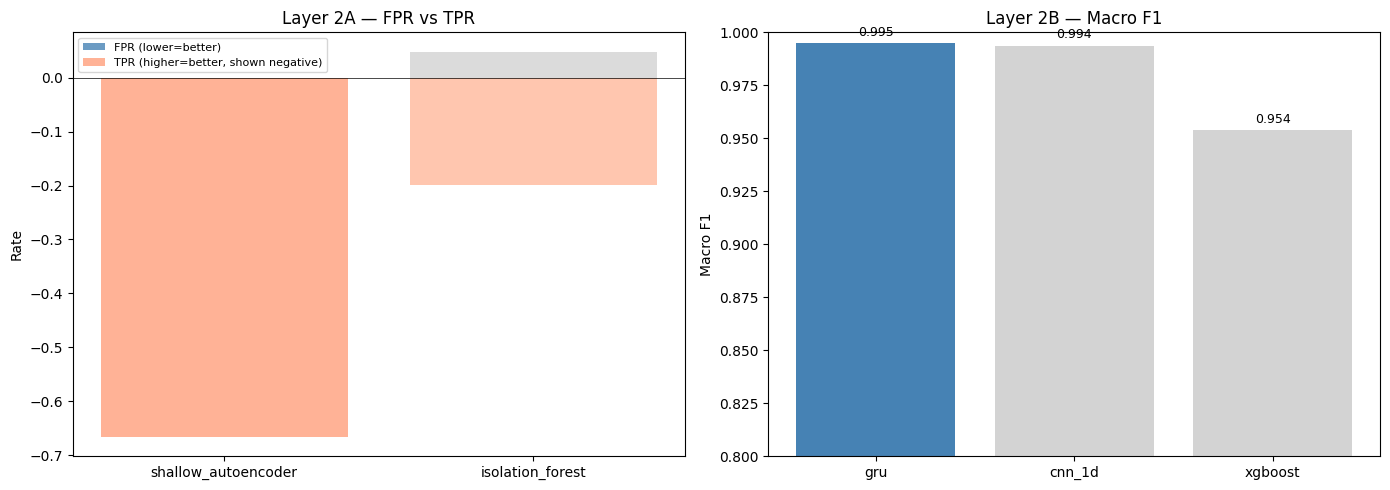

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L2A: FPR vs TPR
models_l2a = [r["model"] for r in l2a_results]
fprs = [r["fpr"] for r in l2a_results]
tprs = [r["tpr"] for r in l2a_results]
colors = ["steelblue" if m == l2a_winner else "lightgray" for m in models_l2a]
bars = axes[0].bar(models_l2a, fprs, color=colors, alpha=0.8, label="FPR (lower=better)")
axes[0].bar(models_l2a, [-t for t in tprs], color=["coral" if m == l2a_winner else "lightsalmon"
            for m in models_l2a], alpha=0.6, label="TPR (higher=better, shown negative)")
axes[0].set_title("Layer 2A — FPR vs TPR")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Rate")

# L2B: Macro F1
models_l2b = [r["model"] for r in l2b_results]
f1s = [r["macro_f1"] for r in l2b_results]
colors_b = ["steelblue" if m == l2b_winner else "lightgray" for m in models_l2b]
axes[1].bar(models_l2b, f1s, color=colors_b)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_title("Layer 2B — Macro F1")
axes[1].set_ylabel("Macro F1")
for bar, f1 in zip(axes[1].patches, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{f1:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/05_model_comparison.png", dpi=120)
plt.show()

## 6. Save full report

In [11]:
save_full_report(l2a_results, l2b_results, lat_results,
                 str(EXPORTS / "full_model_report.json"))
print("Report saved. Copy results to docs/model_selection.md")

[compare] Full report saved → ../exported_models/full_model_report.json
Report saved. Copy results to docs/model_selection.md


## 7. vs Base Paper benchmarks

In [12]:
print("=== Comparison vs Base Papers ===")
print()
print("Base Paper 1 (ADL-WAF, Sameh & Selim):")
print("  Detection accuracy: 99.88%")
print("  Precision:          100%")
print()
print("Base Paper 2 (LSTM+GRU ensemble, Babaey & Faragardi 2025):")
print("  Accuracy:    97.58%")
print("  Precision:   99.99%")
print("  Recall:      97.52%")
print("  Specificity: 99.76%")
print("  FPR:         0.2%")
print()
print("Our Layer 2A results:")
for r in l2a_results:
    print(f"  {r['model']}: TPR={r['tpr']:.4f}  FPR={r['fpr']:.4f}  AUC={r['auc']:.4f}")
print()
print("Our Layer 2B results:")
for r in l2b_results:
    print(f"  {r['model']}: macro_F1={r['macro_f1']:.4f}  acc={r['accuracy']:.4f}")

=== Comparison vs Base Papers ===

Base Paper 1 (ADL-WAF, Sameh & Selim):
  Detection accuracy: 99.88%
  Precision:          100%

Base Paper 2 (LSTM+GRU ensemble, Babaey & Faragardi 2025):
  Accuracy:    97.58%
  Precision:   99.99%
  Recall:      97.52%
  Specificity: 99.76%
  FPR:         0.2%

Our Layer 2A results:
  shallow_autoencoder: TPR=0.6663  FPR=0.0002  AUC=0.9378
  isolation_forest: TPR=0.1984  FPR=0.0485  AUC=0.8722

Our Layer 2B results:
  gru: macro_F1=0.9950  acc=0.9972
  cnn_1d: macro_F1=0.9937  acc=0.9966
  xgboost: macro_F1=0.9540  acc=0.9457
